# Dataset audit and preparation

This notebook records the completed CFPB dataset audit and the reproducible
preparation logic used for the portfolio benchmark. It deliberately avoids raw
complaint previews because narratives may contain sensitive personal or
financial information.

The five executable phases are intended for controlled reproduction only. They
were **not rerun during public-notebook curation**. Aggregate results below are
preserved from the completed experiment.


## Phase 1 ? Configuration and efficient loading

The raw CSV remains local and ignored by Git. Paths are resolved from the
repository root, and the audit reads only required columns in chunks. The
selected modeling period ends on 2026-07-03 even though the source snapshot
contains later ingestion records.


In [ ]:
from pathlib import Path
import html
import re

import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "cfpb_consumer_complaints"
    / "complaints.csv"
)
OUTPUT_PATH = (
    PROJECT_ROOT / "data" / "interim" / "complaints_clean_sample.parquet"
)

START_DATE = "2023-09-01"
END_DATE = "2026-07-03"
CHUNK_SIZE = 250_000
MAX_ROWS_PER_PRODUCT = 12_000
RANDOM_STATE = 42

SOURCE_COLUMNS = [
    "Complaint ID",
    "Date received",
    "Product",
    "Consumer complaint narrative",
]


### Recorded source audit

| Metric | Recorded value |
| --- | ---: |
| Source rows | 17,226,584 |
| Usable narratives | 3,825,572 |
| Missing or empty narratives | 13,401,012 |
| Products in the historical source | 24 |
| Historical source date range | 2011-12-01 to 2026-07-24 |

The historical taxonomy contains renamed and retired labels. Restricting the
period to 2023-09-01 through 2026-07-03 yields 2,297,579 usable narratives and
11 active product classes. That restriction reduces taxonomy mixing while
preserving a substantial recent sample.


## Phase 2 ? Consolidated audit

One chunked pass computes aggregate row, narrative, date, and product coverage.
It never displays complaint text.


In [ ]:
total_rows = 0
usable_narratives = 0
minimum_date = None
maximum_date = None
product_counts = {}

for chunk in pd.read_csv(
    RAW_DATA_PATH,
    usecols=[
        "Date received",
        "Product",
        "Consumer complaint narrative",
    ],
    dtype="string",
    chunksize=CHUNK_SIZE,
):
    total_rows += len(chunk)
    narratives = (
        chunk["Consumer complaint narrative"]
        .fillna("")
        .str.strip()
    )
    usable_mask = narratives.ne("")
    usable_narratives += int(usable_mask.sum())

    counts = (
        chunk.loc[usable_mask, "Product"]
        .fillna("<MISSING_PRODUCT>")
        .value_counts()
    )
    for product, count in counts.items():
        product_counts[product] = product_counts.get(product, 0) + int(count)

    dates = pd.to_datetime(
        chunk.loc[usable_mask, "Date received"],
        errors="coerce",
    ).dropna()
    if not dates.empty:
        chunk_minimum = dates.min()
        chunk_maximum = dates.max()
        minimum_date = chunk_minimum if minimum_date is None else min(minimum_date, chunk_minimum)
        maximum_date = chunk_maximum if maximum_date is None else max(maximum_date, chunk_maximum)

source_audit_df = pd.DataFrame(
    {
        "metric": [
            "total_rows",
            "usable_narratives",
            "missing_or_empty_narratives",
            "products",
            "minimum_date",
            "maximum_date",
        ],
        "value": [
            total_rows,
            usable_narratives,
            total_rows - usable_narratives,
            len(product_counts),
            minimum_date,
            maximum_date,
        ],
    }
)
product_audit_df = (
    pd.Series(product_counts, name="rows_with_narrative")
    .rename_axis("product")
    .sort_values(ascending=False)
    .reset_index()
)
display(source_audit_df)
display(product_audit_df)


## Phase 3 ? Period and deterministic sample selection

The 11 active labels are sampled deterministically using a stable hash rather
than row order. Large classes are capped at 12,000 narratives; the two smaller
classes retain all available records. Only complaint ID, date, product, and
narrative are carried forward. `issue` and `sub_issue` are not model inputs.

### Recorded period distribution

| Product | Usable narratives in period |
| --- | ---: |
| Credit reporting or other personal consumer reports | 1,664,343 |
| Debt collection | 215,098 |
| Checking or savings account | 106,170 |
| Credit card | 105,150 |
| Money transfer, virtual currency, or money service | 85,623 |
| Mortgage | 36,212 |
| Vehicle loan or lease | 26,211 |
| Student loan | 25,789 |
| Payday loan, title loan, personal loan, or advance loan | 17,673 |
| Prepaid card | 9,958 |
| Debt or credit management | 5,352 |


In [ ]:
ACTIVE_PRODUCTS = {
    "Checking or savings account",
    "Credit card",
    "Credit reporting or other personal consumer reports",
    "Debt collection",
    "Debt or credit management",
    "Money transfer, virtual currency, or money service",
    "Mortgage",
    "Payday loan, title loan, personal loan, or advance loan",
    "Prepaid card",
    "Student loan",
    "Vehicle loan or lease",
}

product_samples = {
    product: pd.DataFrame()
    for product in ACTIVE_PRODUCTS
}

for chunk in pd.read_csv(
    RAW_DATA_PATH,
    usecols=SOURCE_COLUMNS,
    dtype="string",
    chunksize=CHUNK_SIZE,
):
    dates = chunk["Date received"].fillna("")
    products = chunk["Product"].fillna("")
    narratives = (
        chunk["Consumer complaint narrative"]
        .fillna("")
        .str.strip()
    )
    selected = chunk.loc[
        dates.between(START_DATE, END_DATE)
        & products.isin(ACTIVE_PRODUCTS)
        & narratives.ne(""),
        SOURCE_COLUMNS,
    ].copy()

    if selected.empty:
        continue

    selected["_sample_key"] = pd.util.hash_pandas_object(
        selected["Complaint ID"].astype(str)
        + "|"
        + selected["Consumer complaint narrative"].astype(str),
        index=False,
    ).astype("uint64")

    for product, product_chunk in selected.groupby("Product"):
        combined = pd.concat(
            [product_samples[product], product_chunk],
            ignore_index=True,
        )
        product_samples[product] = combined.nsmallest(
            MAX_ROWS_PER_PRODUCT,
            "_sample_key",
        )

working_df = (
    pd.concat(product_samples.values(), ignore_index=True)
    .drop(columns="_sample_key")
    .sort_values(["Product", "Complaint ID"])
    .reset_index(drop=True)
)

sample_distribution_df = (
    working_df["Product"]
    .value_counts()
    .rename_axis("product")
    .rename("rows")
    .reset_index()
)
display(sample_distribution_df)


### Recorded sample audit

The deterministic sample initially contained 123,310 rows. It had 123,310
unique complaint IDs, 12,046 rows participating in normalized duplicates, and
2,673 rows whose normalized narrative was associated with conflicting product
labels. Those conflict rows were removed rather than arbitrarily selecting a
label.


## Phase 4 ? Cleaning, deduplication, and export

Cleaning decodes HTML entities, removes tags, and normalizes whitespace while
preserving punctuation, capitalization, and redaction markers. A lowercase copy
is used only as the deduplication key; the model text retains its original case.
Conflicting labels, insufficient text, and duplicate narratives are removed in
that order.


In [ ]:
def clean_complaint_text(text: object) -> str:
    if pd.isna(text):
        return ""
    cleaned = html.unescape(str(text))
    cleaned = re.sub(r"<[^>]+>", " ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned)
    return cleaned.strip()


def create_deduplication_key(text: str) -> str:
    return text.lower().strip()


prepared_df = working_df.copy()
prepared_df["text"] = prepared_df["Consumer complaint narrative"].map(
    clean_complaint_text
)
prepared_df["deduplication_key"] = prepared_df["text"].map(
    create_deduplication_key
)

label_counts = prepared_df.groupby("deduplication_key")["Product"].nunique()
conflicting_keys = label_counts[label_counts.gt(1)].index
prepared_df = prepared_df.loc[
    ~prepared_df["deduplication_key"].isin(conflicting_keys)
].copy()

sufficient_text = (
    prepared_df["text"].str.len().ge(20)
    & prepared_df["text"].str.split().str.len().ge(5)
)
prepared_df = prepared_df.loc[sufficient_text].copy()
prepared_df = (
    prepared_df.sort_values("Complaint ID")
    .drop_duplicates(subset="deduplication_key", keep="first")
)

cleaned_complaints_df = (
    prepared_df[
        ["Complaint ID", "Date received", "Product", "text"]
    ]
    .rename(
        columns={
            "Complaint ID": "complaint_id",
            "Date received": "date_received",
            "Product": "product",
        }
    )
    .sort_values(["product", "complaint_id"])
    .reset_index(drop=True)
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
cleaned_complaints_df.to_parquet(OUTPUT_PATH, index=False)

cleaning_summary_df = pd.DataFrame(
    {
        "metric": ["final_rows", "final_products", "output_path"],
        "value": [
            len(cleaned_complaints_df),
            cleaned_complaints_df["product"].nunique(),
            OUTPUT_PATH.relative_to(PROJECT_ROOT),
        ],
    }
)
final_distribution_df = (
    cleaned_complaints_df["product"]
    .value_counts()
    .rename_axis("product")
    .rename("rows")
    .reset_index()
)
display(cleaning_summary_df)
display(final_distribution_df)


### Recorded clean dataset

| Cleaning result | Rows |
| --- | ---: |
| Initial deterministic sample | 123,310 |
| Removed for conflicting labels | 2,673 |
| Removed as insufficient text | 27 |
| Removed as duplicate narratives | 8,216 |
| **Final clean rows** | **112,394** |

| Product | Final rows |
| --- | ---: |
| Mortgage | 11,992 |
| Payday loan, title loan, personal loan, or advance loan | 11,956 |
| Vehicle loan or lease | 11,945 |
| Student loan | 11,933 |
| Checking or savings account | 11,553 |
| Credit card | 11,280 |
| Prepaid card | 9,903 |
| Debt collection | 9,562 |
| Money transfer, virtual currency, or money service | 8,765 |
| Credit reporting or other personal consumer reports | 8,259 |
| Debt or credit management | 5,246 |


### Recorded class balance and benchmark split

These charts use only the authoritative aggregate counts recorded in this
repository; they do not read complaint records. The class view shows how the
12,000-row cap reduced dominance by the largest source categories while
retaining the smaller classes. The split view confirms the deterministic
70/15/15 benchmark used for leakage-safe model comparison.

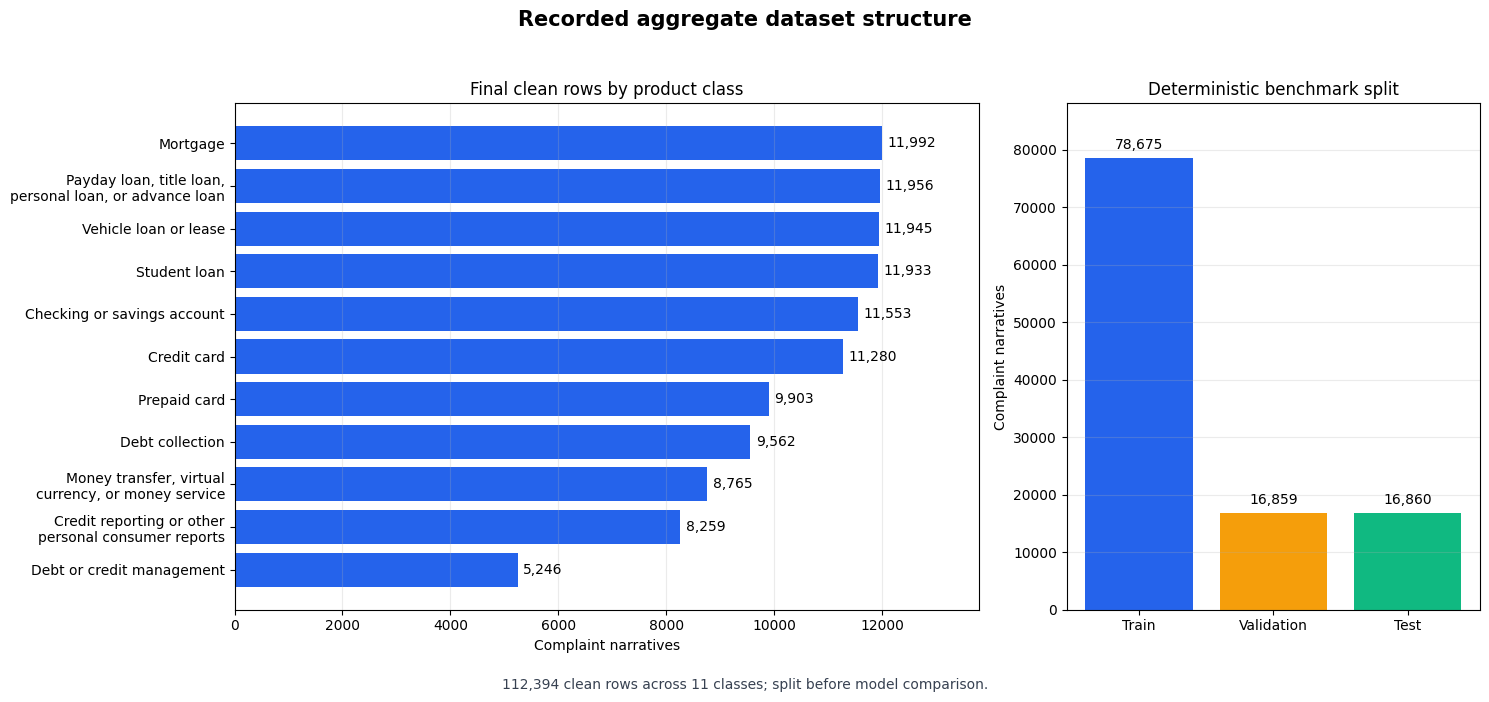

In [1]:
import textwrap

import matplotlib.pyplot as plt

RECORDED_CLASS_ROWS = {
    "Mortgage": 11_992,
    "Payday loan, title loan, personal loan, or advance loan": 11_956,
    "Vehicle loan or lease": 11_945,
    "Student loan": 11_933,
    "Checking or savings account": 11_553,
    "Credit card": 11_280,
    "Prepaid card": 9_903,
    "Debt collection": 9_562,
    "Money transfer, virtual currency, or money service": 8_765,
    "Credit reporting or other personal consumer reports": 8_259,
    "Debt or credit management": 5_246,
}
RECORDED_SPLIT_ROWS = {
    "Train": 78_675,
    "Validation": 16_859,
    "Test": 16_860,
}

ordered_classes = sorted(
    RECORDED_CLASS_ROWS.items(),
    key=lambda item: item[1],
)
class_labels = [textwrap.fill(label, width=31) for label, _ in ordered_classes]
class_rows = [rows for _, rows in ordered_classes]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7),
    gridspec_kw={"width_ratios": [1.8, 1]},
)

class_bars = axes[0].barh(class_labels, class_rows, color="#2563EB")
axes[0].bar_label(class_bars, labels=[f"{rows:,}" for rows in class_rows], padding=4)
axes[0].set_title("Final clean rows by product class")
axes[0].set_xlabel("Complaint narratives")
axes[0].set_xlim(0, max(class_rows) * 1.15)
axes[0].grid(axis="x", alpha=0.25)

split_labels = list(RECORDED_SPLIT_ROWS)
split_rows = list(RECORDED_SPLIT_ROWS.values())
split_bars = axes[1].bar(
    split_labels,
    split_rows,
    color=["#2563EB", "#F59E0B", "#10B981"],
)
axes[1].bar_label(split_bars, labels=[f"{rows:,}" for rows in split_rows], padding=4)
axes[1].set_title("Deterministic benchmark split")
axes[1].set_ylabel("Complaint narratives")
axes[1].set_ylim(0, max(split_rows) * 1.12)
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("Recorded aggregate dataset structure", fontsize=15, fontweight="bold")
figure.text(
    0.5,
    0.01,
    "112,394 clean rows across 11 classes; split before model comparison.",
    ha="center",
    color="#374151",
)
figure.tight_layout(rect=(0, 0.04, 1, 0.95))
plt.show()


## Phase 5 ? Final integrity checks and decisions

This final phase reads only the prepared artifact and reports aggregate checks.
It does not preview narratives.


In [ ]:
final_df = pd.read_parquet(
    OUTPUT_PATH,
    columns=["complaint_id", "date_received", "product", "text"],
)

assert len(final_df) == 112_394
assert final_df["product"].nunique() == 11
assert not final_df["complaint_id"].duplicated().any()
assert not final_df["text"].str.lower().str.strip().duplicated().any()

final_summary_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "products",
            "minimum_date",
            "maximum_date",
            "empty_texts",
        ],
        "value": [
            len(final_df),
            final_df["product"].nunique(),
            final_df["date_received"].min(),
            final_df["date_received"].max(),
            int(final_df["text"].str.strip().eq("").sum()),
        ],
    }
)
display(final_summary_df)


## Conclusions and limitations

- The final artifact has 112,394 rows, 11 classes, and a selected date range of
  2023-09-01 through 2026-07-03.
- Capping large classes makes experimentation practical but changes the source
  class distribution.
- Historical product labels and future taxonomy changes remain a risk.
- Deduplication prevents exact narrative overlap, but it does not guarantee
  semantic independence between records.
- Complaint narratives may contain sensitive information; raw previews and
  prediction-level records must remain outside the public repository.
